In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from polars import selectors as cs
from sklearn.model_selection import train_test_split
from typing import cast

sys.path.append(r"../baseline_v2")
from add_features import add_modified_features
from load_data import load_data
from preprocess import build_preprocessor, build_target_transformer

%matplotlib inline

warnings.filterwarnings('ignore')

## Data Preprocessing

### load

In [2]:
train, test = load_data()
train.shape, test.shape

((1458, 80), (1459, 79))

### prepare

In [3]:
X = train.copy()
y = X.pop('SalePrice')
X_test = test.copy()

### build pipeline

In [4]:
log_standardize_y = build_target_transformer()
tree_preprocessor, reg_preprocessor = build_preprocessor()

### add modified -> drop useless -> filter outlier ->train test split

In [5]:
# add modified
X = add_modified_features(pl.DataFrame(X))
X_test = add_modified_features(pl.DataFrame(X_test))
X.index = y.index

# split
X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_va.shape, y_train.shape, y_va.shape

((1166, 106), (292, 106), (1166,), (292,))

In [6]:
s = X_train.isnull().sum()
s[s > 0]

Series([], dtype: int64)

In [7]:
transformed_X_train = reg_preprocessor.fit_transform(X_train,y_train)
transformed_X_train = cast(np.ndarray,transformed_X_train)
transformed_X_train_df = pd.DataFrame(data=transformed_X_train,columns=reg_preprocessor.get_feature_names_out())
transformed_X_train_df.shape

(1166, 75)

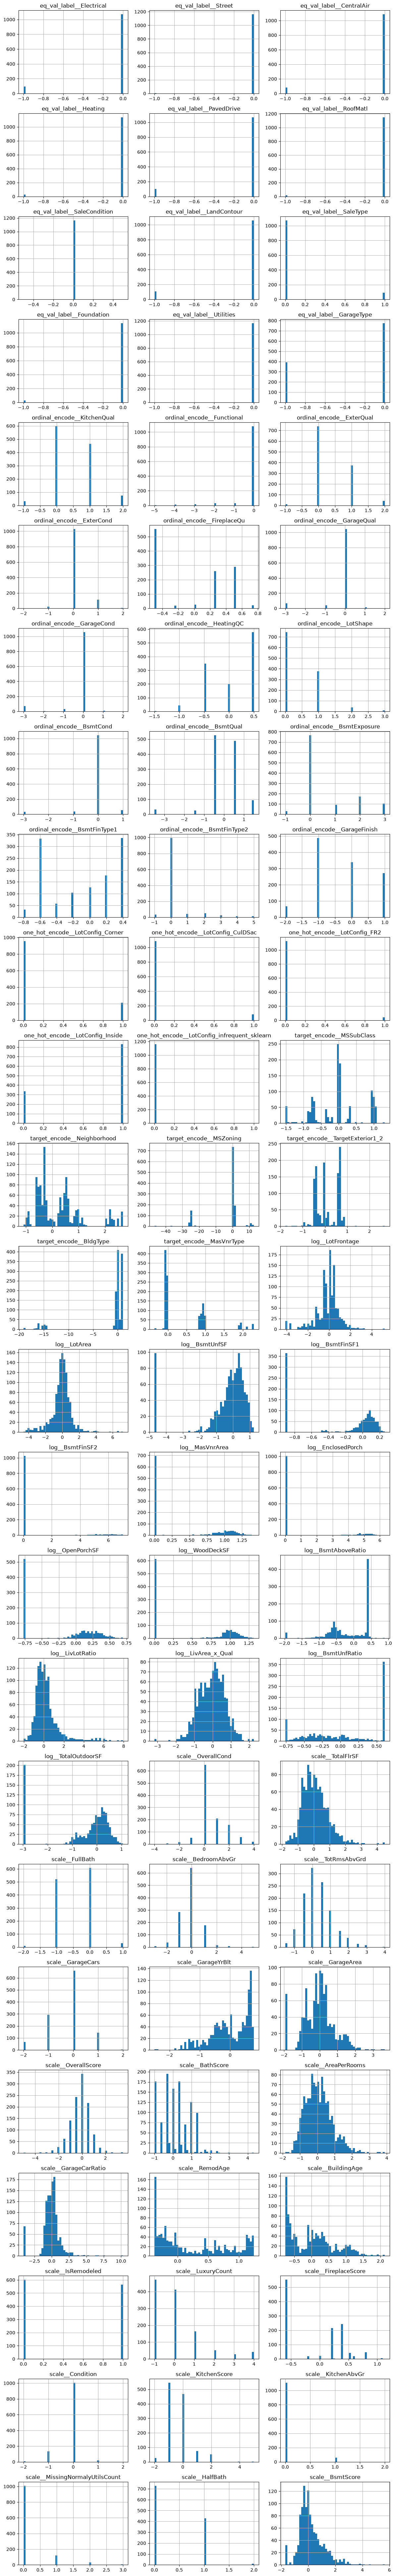

In [8]:

transformed_X_train_df.hist(figsize=(12,90), bins=50,layout=(29,3))
plt.tight_layout()

In [12]:
threshold = 0.7

corr = transformed_X_train_df.corr()

# 対角成分と重複する組み合わせを除外
upper_mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

high_corr = (
    corr.where(upper_mask)
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
    })
)

# 相関係数の絶対値でフィルタ
high_corr = (
    high_corr.loc[high_corr["correlation"].abs() >= threshold]
    .assign(abs_correlation=lambda df: df["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

high_corr

,feature_1,feature_2,correlation,abs_correlation
0,ordinal_encode__FireplaceQu,scale__FireplaceScore,0.976581,0.976581
1,ordinal_encode__GarageQual,ordinal_encode__GarageCond,0.959495,0.959495
2,scale__GarageCars,scale__GarageArea,0.889450,0.889450
3,ordinal_encode__BsmtFinType2,log__BsmtFinSF2,0.866037,0.866037
4,log__LivArea_x_Qual,scale__TotalFlrSF,0.855825,0.855825
5,scale__GarageYrBlt,scale__BuildingAge,-0.852626,0.852626
6,ordinal_encode__BsmtFinType1,log__BsmtFinSF1,0.846357,0.846357
7,target_encode__MasVnrType,log__MasVnrArea,0.842281,0.842281
8,eq_val_label__PavedDrive,scale__MissingNormalyUtilsCount,-0.803600,0.803600
9,scale__TotalFlrSF,scale__BsmtScore,0.792869,0.792869
